# Poles vs No-Poles — Effort Analysis

**Study design**
| | Segment 1 (loose terrain, ~+85 m, 4:13) | Segment 2 (paved, ~+57 m, 2:25) |
|---|---|---|
| Run order | A (poles) → B (no poles) | B (no poles) → A (poles) |
| After each | watch stopped 60 s for HRR | watch stopped 60 s for HRR |

Segments are identified via **lap markers** (COROS lap button).  
HRR is computed as: HR at lap end − average HR in the window [t_end+55 s, t_end+65 s] of absolute time.

In [3]:
import fitdecode
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ──────────────────────────────────────────────────────────────────
FIT_FILE = "../data/test-poles/20260514.fit"   # <-- your file path

# 0-indexed lap positions for the 4 effort segments inside the activity
# (3rd, 5th, 7th, 9th lap → indices 2, 4, 6, 8)
EFFORT_LAP_INDICES = [2, 4, 6, 8]

# Segment metadata — order matches EFFORT_LAP_INDICES
SEGMENTS = {
    "seg1_A": dict(label="Seg 1 · poles",    terrain="loose", condition="poles",    order=1),
    "seg1_B": dict(label="Seg 1 · no poles", terrain="loose", condition="no_poles", order=2),
    "seg2_B": dict(label="Seg 2 · no poles", terrain="paved", condition="no_poles", order=1),
    "seg2_A": dict(label="Seg 2 · poles",    terrain="paved", condition="poles",    order=2),
}

# HRR: seconds after lap end where we expect HR to be measured
HRR_TARGET_SEC  = 60   # centre of the window
HRR_TOLERANCE   = 5    # ± seconds around the target

# Timer-stop detection: gap in record stream larger than this = watch was stopped
TIMER_STOP_GAP_SEC = 5

# Manual override — uncomment and fill if lap detection fails
# MANUAL_SEGMENTS = [
#     (datetime(2025, 5, 14, 10,  0,  0), datetime(2025, 5, 14, 10,  4, 13)),  # seg1 A
#     (datetime(2025, 5, 14, 10,  5, 30), datetime(2025, 5, 14, 10,  9, 43)),  # seg1 B
#     (datetime(2025, 5, 14, 10, 15,  0), datetime(2025, 5, 14, 10, 17, 25)),  # seg2 B
#     (datetime(2025, 5, 14, 10, 19,  0), datetime(2025, 5, 14, 10, 21, 25)),  # seg2 A
# ]
MANUAL_SEGMENTS = None
# ────────────────────────────────────────────────────────────────────────────

## 1 · Load FIT file

In [4]:
def load_fit(path):
    records, laps = [], []
    with fitdecode.FitReader(path) as fit:
        for frame in fit:
            if frame.frame_type != fitdecode.FIT_FRAME_DATA:
                continue
            if frame.name == 'record':
                row = {f.name: f.value for f in frame.fields}
                if hasattr(frame, 'developer_fields'):
                    for f in frame.developer_fields:
                        row[f'dev_{f.name}'] = f.value
                records.append(row)
            elif frame.name == 'lap':
                laps.append({f.name: f.value for f in frame.fields})

    df      = pd.DataFrame(records)
    df_laps = pd.DataFrame(laps)

    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    if not df_laps.empty:
        df_laps['start_time'] = pd.to_datetime(df_laps['start_time'], utc=True)
        df_laps['timestamp']  = pd.to_datetime(df_laps['timestamp'],  utc=True)
    df = df.sort_values('timestamp').reset_index(drop=True)

    print(f"Records : {len(df):,}")
    print(f"Laps    : {len(df_laps)}")
    print(f"Fields  : {sorted(df.columns.tolist())}")
    return df, df_laps

df_raw, df_laps = load_fit(FIT_FILE)

Records : 5,963
Laps    : 10
Fields  : ['Effort Pace', 'accumulated_power', 'activity_type', 'altitude', 'cadence', 'distance', 'enhanced_altitude', 'enhanced_speed', 'heart_rate', 'position_lat', 'position_long', 'power', 'speed', 'stance_time', 'stance_time_balance', 'step_length', 'timestamp', 'vertical_oscillation', 'vertical_ratio']


In [5]:
df_raw.head(3)

,activity_type,timestamp,distance,position_lat,position_long,heart_rate,enhanced_speed,speed,step_length,Effort Pace,cadence,power,accumulated_power,enhanced_altitude,altitude,stance_time,stance_time_balance,vertical_oscillation,vertical_ratio
0,running,2026-05-14 16:03:30+00:00,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,running,2026-05-14 16:03:31+00:00,0.0,343159456.0,-213507989.0,96.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,running,2026-05-14 16:03:32+00:00,0.0,343159339.0,-213507933.0,95.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Inspect all laps — use this to verify EFFORT_LAP_INDICES
cols = [c for c in ['start_time','timestamp','total_elapsed_time','total_distance',
                    'avg_heart_rate'] if c in df_laps.columns]
df_laps[cols].to_string()

'                 start_time                 timestamp  total_elapsed_time  total_distance  avg_heart_rate\n0 2026-05-14 16:03:30+00:00 2026-05-14 16:42:21+00:00             2331.02         5232.08             144\n1 2026-05-14 16:42:21+00:00 2026-05-14 16:52:09+00:00              588.17          341.78             152\n2 2026-05-14 16:52:09+00:00 2026-05-14 16:56:22+00:00              252.92          359.47             167\n3 2026-05-14 16:56:22+00:00 2026-05-14 17:00:23+00:00              241.49          371.57             144\n4 2026-05-14 17:00:23+00:00 2026-05-14 17:05:43+00:00              319.58          364.01             166\n5 2026-05-14 17:05:43+00:00 2026-05-14 17:11:01+00:00              318.56          134.06             139\n6 2026-05-14 17:11:01+00:00 2026-05-14 17:13:31+00:00              149.45          284.12             167\n7 2026-05-14 17:13:31+00:00 2026-05-14 17:18:30+00:00              299.08          353.63             136\n8 2026-05-14 17:18:30+00:00 2026-05-

## 2 · Feature engineering

In [7]:
df = df_raw.copy()

speed_col = 'enhanced_speed' if 'enhanced_speed' in df.columns else 'speed'
df['speed_ms']  = pd.to_numeric(df[speed_col], errors='coerce')
df['pace_mpkm'] = np.where(df['speed_ms'] > 0.1, 1000 / df['speed_ms'] / 60, np.nan)

alt_col = 'enhanced_altitude' if 'enhanced_altitude' in df.columns else 'altitude'
df['alt']        = pd.to_numeric(df[alt_col], errors='coerce')
df['alt_smooth'] = df['alt'].rolling(5, center=True, min_periods=1).mean()
df['dist_smooth']= df['distance'].rolling(5, center=True, min_periods=1).mean()
df['delta_alt']  = df['alt_smooth'].diff()
df['delta_dist'] = df['dist_smooth'].diff().clip(lower=1e-3)
df['grade_pct']  = (df['delta_alt'] / df['delta_dist'] * 100).clip(-60, 60)
df['gap_mpkm']   = df['pace_mpkm'] * (1 + df['grade_pct'].fillna(0) / 10)

for src, dst in [('step_length','step_len_m'),('cadence','cadence'),
                 ('power','power'),('vertical_oscillation','vert_osc'),
                 ('stance_time','stance_ms')]:
    for cand in [src, f'dev_{src}']:
        if cand in df.columns:
            df[dst] = pd.to_numeric(df[cand], errors='coerce')
            break

if 'step_len_m' in df.columns and df['step_len_m'].median() > 10:
    df['step_len_m'] = df['step_len_m'] / 1000

df['hr'] = pd.to_numeric(df['heart_rate'], errors='coerce')

print("Derived:", [c for c in ['speed_ms','pace_mpkm','alt','grade_pct','gap_mpkm',
      'step_len_m','cadence','power','vert_osc','stance_ms','hr'] if c in df.columns])

Derived: ['speed_ms', 'pace_mpkm', 'alt', 'grade_pct', 'gap_mpkm', 'step_len_m', 'cadence', 'power', 'vert_osc', 'stance_ms', 'hr']


## 3 · Segment detection

In [8]:
def segments_from_laps(df_laps, indices):
    if df_laps.empty:
        return None
    if not all(c in df_laps.columns for c in ['start_time', 'timestamp']):
        return None

    laps_sorted = df_laps.sort_values('start_time').reset_index(drop=True)
    print(f"Total laps in file: {len(laps_sorted)}")

    if max(indices) >= len(laps_sorted):
        print(f"ERROR: index {max(indices)} out of range — only {len(laps_sorted)} laps found.")
        print("All laps:")
        cols = [c for c in ['start_time','timestamp','total_elapsed_time'] if c in laps_sorted.columns]
        print(laps_sorted[cols].to_string())
        return None

    effort = laps_sorted.iloc[indices]
    segs   = [(row.start_time, row.timestamp) for _, row in effort.iterrows()]
    print(f"Using lap indices {indices}:")
    for i, (s, e) in enumerate(segs):
        dur = (e - s).total_seconds()
        print(f"  [{indices[i]}] {s.strftime('%H:%M:%S')} → {e.strftime('%H:%M:%S')}  ({dur:.0f} s)")
    return segs


def segments_from_manual(manual_list):
    result = []
    for s, e in manual_list:
        s = pd.Timestamp(s, tz='UTC') if s.tzinfo is None else pd.Timestamp(s)
        e = pd.Timestamp(e, tz='UTC') if e.tzinfo is None else pd.Timestamp(e)
        result.append((s, e))
    return result


if MANUAL_SEGMENTS is not None:
    seg_bounds = segments_from_manual(MANUAL_SEGMENTS)
    print("Using manual segment boundaries.")
else:
    seg_bounds = segments_from_laps(df_laps, EFFORT_LAP_INDICES)
    if seg_bounds is None:
        print("\nLap detection failed — set MANUAL_SEGMENTS in cell 1 and re-run.")

seg_keys = list(SEGMENTS.keys())
SEG = {seg_keys[i]: seg_bounds[i] for i in range(len(seg_bounds))} if seg_bounds else {}

Total laps in file: 10
Using lap indices [2, 4, 6, 8]:
  [2] 16:52:09 → 16:56:22  (253 s)
  [4] 17:00:23 → 17:05:43  (320 s)
  [6] 17:11:01 → 17:13:31  (150 s)
  [8] 17:18:30 → 17:20:59  (149 s)


## 4 · Per-segment extraction

In [10]:
MECH_COLS = ['hr','pace_mpkm','gap_mpkm','grade_pct',
             'step_len_m','cadence','power','vert_osc','stance_ms']


def extract_segment(df, t_start, t_end, gap_sec=TIMER_STOP_GAP_SEC):
    """Slice to [t_start, t_end] then cut at the first timer-stop gap.
    Returns (trimmed_df, true_end_timestamp).
    """
    mask = (df['timestamp'] >= t_start) & (df['timestamp'] <= t_end)
    seg  = df.loc[mask].copy().reset_index(drop=True)
    if seg.empty:
        return seg, t_end

    gaps     = seg['timestamp'].diff().dt.total_seconds()
    stop_idx = gaps[gaps > gap_sec].index
    if len(stop_idx):
        cut      = stop_idx[0]
        true_end = seg.loc[cut - 1, 'timestamp']
        seg      = seg.loc[:cut - 1].copy()
        print(f"  [{t_start.strftime('%H:%M:%S')}] timer-stop gap at row {cut}, "
              f"trimmed to {true_end.strftime('%H:%M:%S')}")
    else:
        true_end = seg['timestamp'].max()
    return seg, true_end


def compute_hrr(df, true_end,
                target_sec=HRR_TARGET_SEC,
                tolerance_sec=HRR_TOLERANCE):
    """HRR60 = HR at lap end − avg HR in [true_end+55s, true_end+65s].

    The watch was stopped during recovery, so there are no records in that gap.
    We look in absolute wall-clock time for records that fall in the window,
    which will be early in the NEXT lap or a transition period.
    """
    # HR at the very end of the effort
    hr_end_vals = df[df['timestamp'] <= true_end]['hr'].dropna()
    if hr_end_vals.empty:
        return dict(hr_end=np.nan, hr_60s=np.nan, hrr60=np.nan)
    hr_end = float(hr_end_vals.iloc[-1])

    # HR window 60 s ± tolerance in absolute time
    t_lo = true_end + pd.Timedelta(seconds=target_sec - tolerance_sec)
    t_hi = true_end + pd.Timedelta(seconds=target_sec + tolerance_sec*2)
    window = df[(df['timestamp'] >= t_lo) & (df['timestamp'] <= t_hi)]['hr'].dropna()

    if window.empty:
        print(f"  WARNING: no records found in [{t_lo.strftime('%H:%M:%S')}, "
              f"{t_hi.strftime('%H:%M:%S')}] — HRR will be NaN. "
              f"Check HRR_TARGET_SEC / HRR_TOLERANCE or the lap timing.")
        hr_60s = np.nan
    else:
        hr_60s = float(window.mean())
        print(f"  HRR window: {len(window)} records, "
              f"avg HR = {hr_60s:.1f} bpm  (end HR = {hr_end:.0f} bpm)")

    return dict(hr_end=hr_end, hr_60s=hr_60s, hrr60=hr_end - hr_60s)


def segment_stats(seg_df, label):
    stats = {'label': label}
    if seg_df.empty:
        stats['duration_s'] = 0
        return stats
    stats['duration_s'] = (seg_df['timestamp'].max() - seg_df['timestamp'].min()).total_seconds()
    for col in MECH_COLS:
        if col in seg_df.columns:
            vals = seg_df[col].dropna()
            if len(vals):
                stats[f'{col}_mean'] = vals.mean()
                stats[f'{col}_max']  = vals.max()
    if 'alt' in seg_df.columns:
        diffs = seg_df['alt'].diff().dropna()
        stats['elev_gain_m'] = diffs[diffs > 0].sum()
    return stats


# ── Extract ──────────────────────────────────────────────────────────────────
segments_df  = {}
summary_rows = []

for key, (t_start, t_end) in SEG.items():
    print(f"\n{SEGMENTS[key]['label']}")
    seg_df, true_end = extract_segment(df, t_start, t_end)
    hrr              = compute_hrr(df, true_end)

    segments_df[key] = seg_df

    row = segment_stats(seg_df, SEGMENTS[key]['label'])
    row.update(SEGMENTS[key])
    row['hr_at_end'] = hrr['hr_end']
    row['hr_at_60s'] = hrr['hr_60s']
    row['hrr60_bpm'] = hrr['hrr60']
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index('label')

cols_show = [c for c in ['duration_s','elev_gain_m','hr_mean','hr_max',
             'hr_at_end','hr_at_60s','hrr60_bpm',
             'pace_mpkm_mean','gap_mpkm_mean',
             'power_mean','cadence_mean','step_len_m_mean'] if c in summary.columns]
summary[cols_show].round(2)


Seg 1 · poles
  HRR window: 7 records, avg HR = 146.0 bpm  (end HR = 175 bpm)

Seg 1 · no poles
  [17:00:23] timer-stop gap at row 257, trimmed to 17:04:39
  HRR window: 10 records, avg HR = 144.5 bpm  (end HR = 177 bpm)

Seg 2 · no poles
  HRR window: 5 records, avg HR = 143.2 bpm  (end HR = 175 bpm)

Seg 2 · poles
  HRR window: 9 records, avg HR = 132.6 bpm  (end HR = 176 bpm)


,duration_s,elev_gain_m,hr_mean,hr_max,hr_at_end,hr_at_60s,hrr60_bpm,pace_mpkm_mean,gap_mpkm_mean,power_mean,cadence_mean,step_len_m_mean
label,,,,,,,,,,,,
Seg 1 · poles,253.0,84.0,166.87,175.0,175.0,146.00,29.00,11.92,40.93,285.78,64.54,0.67
Seg 1 · no poles,256.0,85.0,166.70,177.0,177.0,144.50,32.50,11.88,40.10,281.02,64.25,0.67
Seg 2 · no poles,150.0,53.0,167.40,175.0,175.0,143.20,31.80,8.81,25.69,320.50,82.44,0.70
Seg 2 · poles,149.0,58.0,167.26,178.0,176.0,132.56,43.44,8.37,25.81,350.97,77.49,0.79


## 5 · Poles vs no-poles comparison

In [11]:
def diff_table(summary, terrain):
    sub      = summary[summary['terrain'] == terrain]
    poles    = sub[sub['condition'] == 'poles']
    no_poles = sub[sub['condition'] == 'no_poles']
    rows = []
    for m in [c for c in cols_show if c not in ['duration_s','elev_gain_m']]:
        if m not in poles.columns:
            continue
        pv  = poles[m].values[0]    if len(poles)    else np.nan
        npv = no_poles[m].values[0] if len(no_poles) else np.nan
        delta = pv - npv
        rows.append({'metric': m, 'poles': pv, 'no_poles': npv,
                     'delta (poles−no)': delta,
                     'delta %': 100 * delta / npv if npv else np.nan})
    return pd.DataFrame(rows).set_index('metric').round(3)

print("=== Segment 1 — LOOSE TERRAIN ===")
display(diff_table(summary, 'loose'))
print("\n=== Segment 2 — PAVED ===")
display(diff_table(summary, 'paved'))

=== Segment 1 — LOOSE TERRAIN ===


,poles,no_poles,delta (poles−no),delta %
metric,,,,
hr_mean,166.874,166.700,0.174,0.104
hr_max,175.000,177.000,-2.000,-1.130
hr_at_end,175.000,177.000,-2.000,-1.130
hr_at_60s,146.000,144.500,1.500,1.038
hrr60_bpm,29.000,32.500,-3.500,-10.769
pace_mpkm_mean,11.918,11.878,0.039,0.332
gap_mpkm_mean,40.926,40.102,0.824,2.056
power_mean,285.780,281.019,4.760,1.694
cadence_mean,64.539,64.253,0.286,0.446



=== Segment 2 — PAVED ===


,poles,no_poles,delta (poles−no),delta %
metric,,,,
hr_mean,167.264,167.404,-0.140,-0.084
hr_max,178.000,175.000,3.000,1.714
hr_at_end,176.000,175.000,1.000,0.571
hr_at_60s,132.556,143.200,-10.644,-7.433
hrr60_bpm,43.444,31.800,11.644,36.618
pace_mpkm_mean,8.366,8.814,-0.449,-5.092
gap_mpkm_mean,25.809,25.685,0.124,0.482
power_mean,350.973,320.497,30.476,9.509
cadence_mean,77.486,82.444,-4.957,-6.013


## 6 · Detailed time-series plots

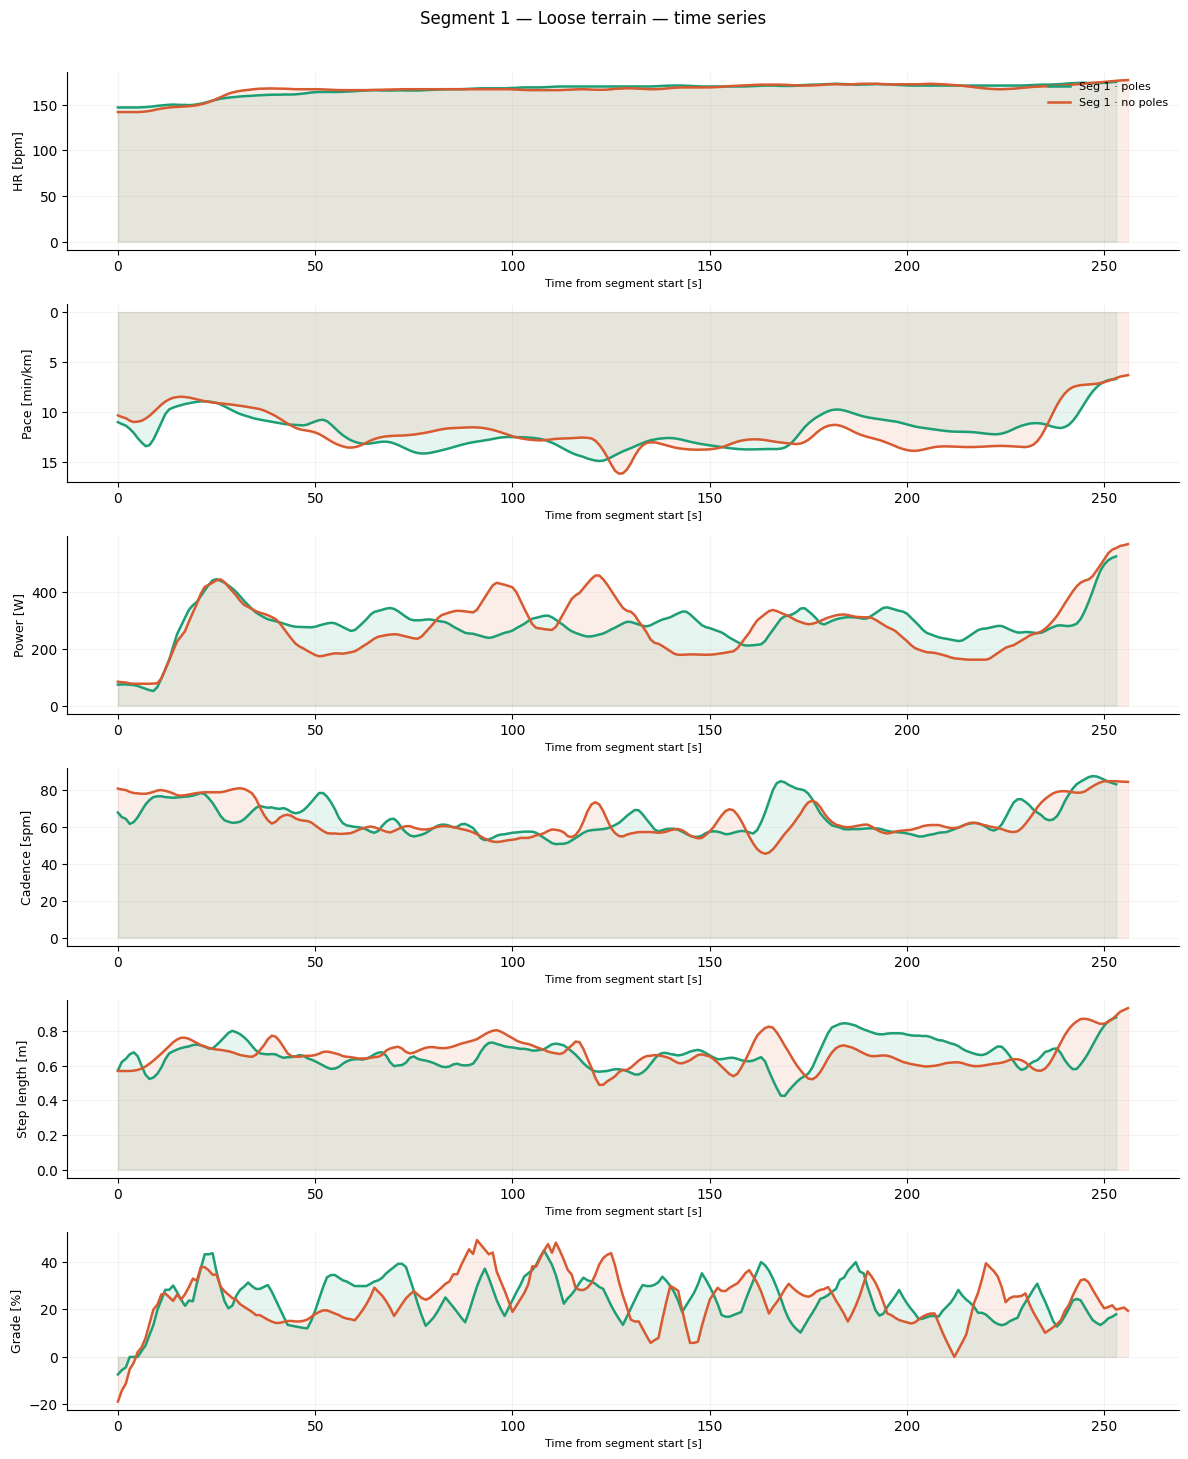

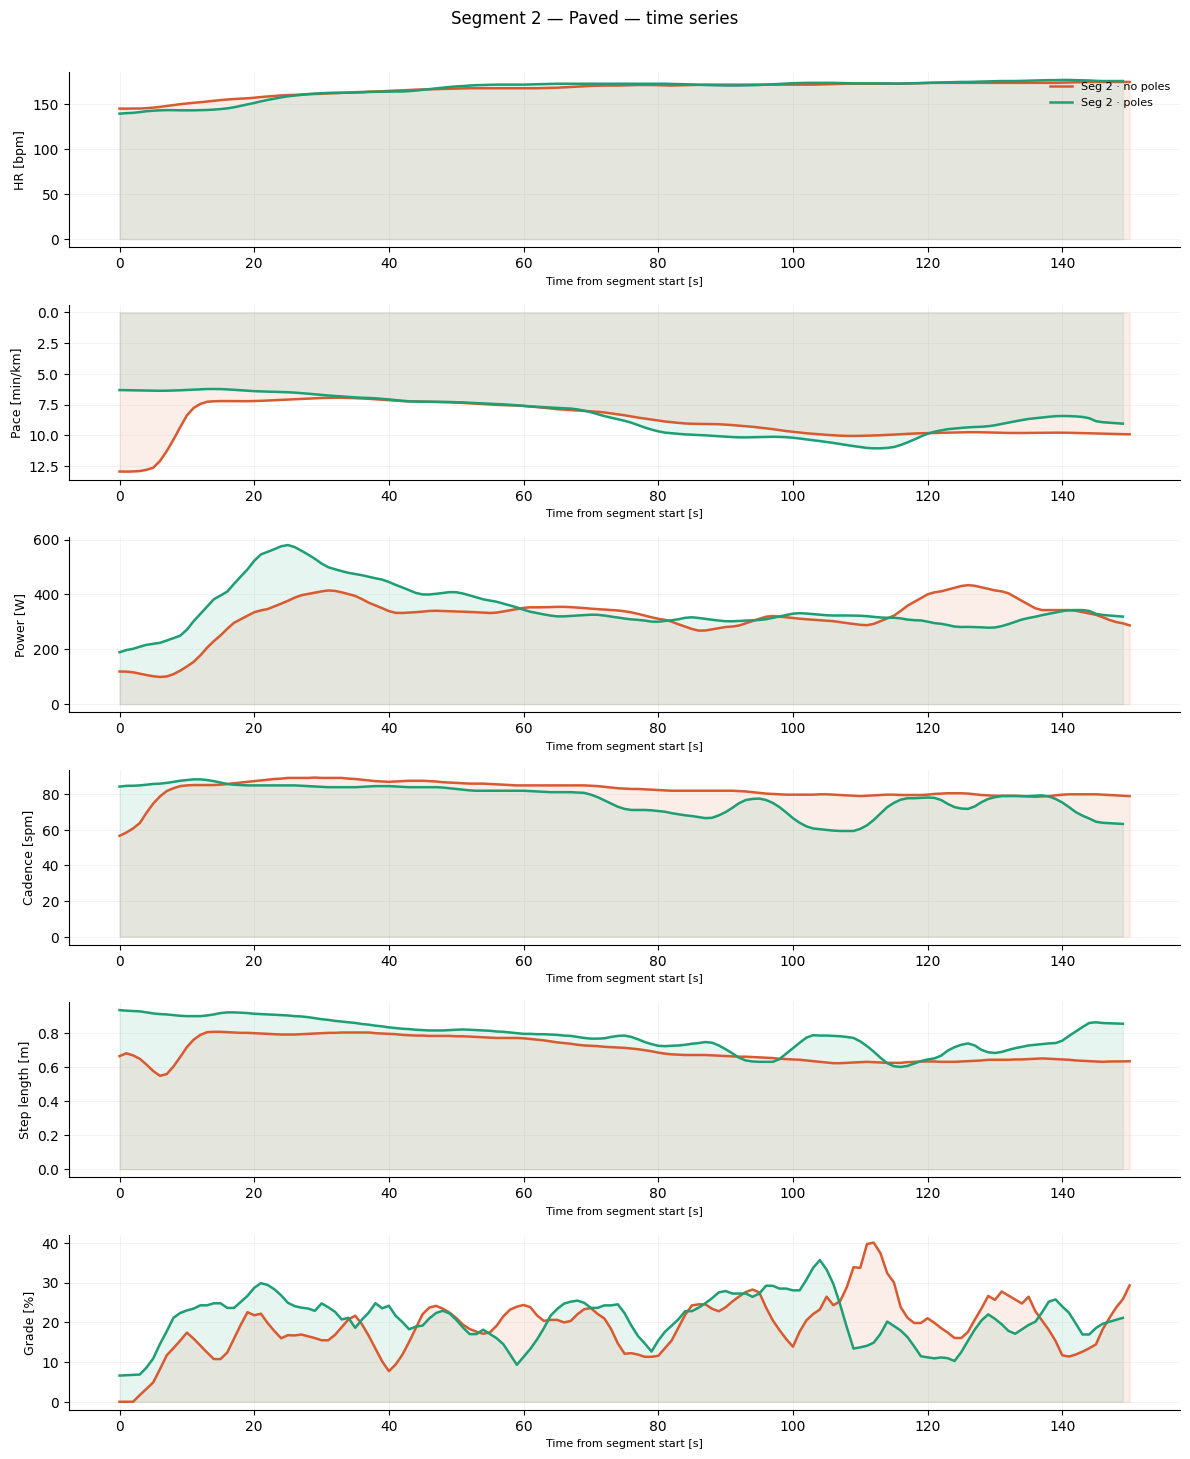

In [12]:
COLOR = {'poles': '#1D9E75', 'no_poles': '#D85A30'}

def rolling(s, w=5):
    return s.rolling(w, center=True, min_periods=1).mean()

def plot_terrain(terrain_key, terrain_label):
    pairs = {k: v for k, v in SEG.items() if SEGMENTS[k]['terrain'] == terrain_key}
    mechs = [m for m in ['hr','pace_mpkm','power','cadence','step_len_m','grade_pct']
             if m in df.columns]
    fig, axes = plt.subplots(len(mechs), 1, figsize=(12, 2.4 * len(mechs)), sharex=False)
    if len(mechs) == 1: axes = [axes]
    ylabels = {'hr':'HR [bpm]','pace_mpkm':'Pace [min/km]','gap_mpkm':'GAP [min/km]',
               'power':'Power [W]','cadence':'Cadence [spm]','step_len_m':'Step length [m]',
               'grade_pct':'Grade [%]','vert_osc':'Vert. osc. [mm]','stance_ms':'Stance [ms]'}
    for ax, metric in zip(axes, mechs):
        for key in pairs:
            seg_df = segments_df[key]
            if metric not in seg_df.columns: continue
            color = COLOR[SEGMENTS[key]['condition']]
            t0    = seg_df['timestamp'].min()
            secs  = (seg_df['timestamp'] - t0).dt.total_seconds()
            vals  = rolling(seg_df[metric])
            ax.plot(secs, vals, color=color, lw=1.8, label=SEGMENTS[key]['label'])
            ax.fill_between(secs, vals, alpha=0.10, color=color)
        ax.set_ylabel(ylabels.get(metric, metric), fontsize=9)
        ax.set_xlabel('Time from segment start [s]', fontsize=8)
        ax.grid(True, alpha=0.2, lw=0.5)
        ax.spines[['top','right']].set_visible(False)
        if metric == 'pace_mpkm': ax.invert_yaxis()
    axes[0].legend(loc='upper right', fontsize=8, frameon=False)
    fig.suptitle(f"{terrain_label} — time series", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f"timeseries_{terrain_key}.png", dpi=200, bbox_inches='tight')
    plt.show()

plot_terrain('loose', 'Segment 1 — Loose terrain')
plot_terrain('paved', 'Segment 2 — Paved')

## 7 · HRR — bar chart

Since the watch was stopped during recovery, there is no continuous HR curve.
Instead we plot two bars per segment: **HR at lap end** and **HR at 60 s**,
with the HRR60 drop annotated.

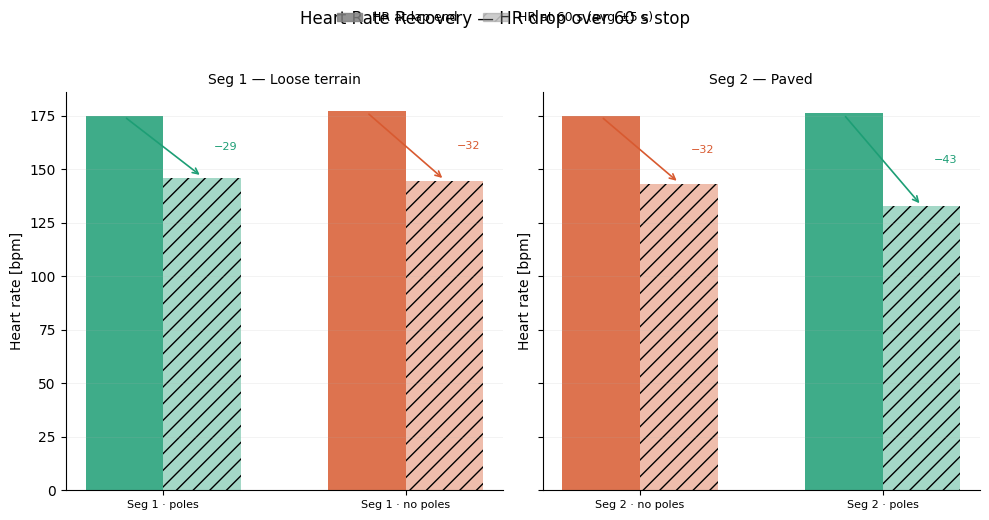

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, terrain_key, terrain_label in zip(
    axes, ['loose', 'paved'], ['Seg 1 — Loose terrain', 'Seg 2 — Paved']
):
    sub_keys = [k for k in SEG if SEGMENTS[k]['terrain'] == terrain_key]
    n        = len(sub_keys)
    x_pos    = np.arange(n)
    bar_w    = 0.32

    for xi, key in enumerate(sub_keys):
        row   = summary.loc[SEGMENTS[key]['label']]
        color = COLOR[SEGMENTS[key]['condition']]
        label = SEGMENTS[key]['label']

        hr_end = row.get('hr_at_end', np.nan)
        hr_60s = row.get('hr_at_60s', np.nan)
        hrr60  = row.get('hrr60_bpm', np.nan)

        # Two bars side by side: end HR (solid) and 60 s HR (hatched)
        ax.bar(xi - bar_w/2, hr_end, width=bar_w, color=color, alpha=0.85,
               label=f"{label} (end)" if xi == 0 else "")
        ax.bar(xi + bar_w/2, hr_60s, width=bar_w, color=color, alpha=0.40,
               hatch='//', label=f"{label} (60 s)" if xi == 0 else "")

        # Annotate drop
        if not np.isnan(hrr60):
            y_top = max(hr_end, hr_60s) + 1
            ax.annotate("", xy=(xi + bar_w/2, hr_60s + 0.5),
                        xytext=(xi - bar_w/2, hr_end - 0.5),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
            ax.text(xi + bar_w/2 + 0.05, (hr_end + hr_60s) / 2,
                    f"−{hrr60:.0f}", fontsize=8, color=color, va='center')

    ax.set_xticks(x_pos)
    ax.set_xticklabels([SEGMENTS[k]['label'] for k in sub_keys], fontsize=8)
    ax.set_title(terrain_label, fontsize=10)
    ax.set_ylabel('Heart rate [bpm]')
    ax.grid(axis='y', alpha=0.2, lw=0.5)
    ax.spines[['top','right']].set_visible(False)

# Manual legend
from matplotlib.patches import Patch
handles = [
    Patch(color='gray', alpha=0.85,            label='HR at lap end'),
    Patch(color='gray', alpha=0.40, hatch='//', label='HR at 60 s (avg ±5 s)'),
]
fig.legend(handles=handles, loc='upper center', ncol=2, fontsize=9, frameon=False)
fig.suptitle('Heart Rate Recovery — HR drop over 60 s stop', y=1.03, fontsize=12)
plt.tight_layout()
plt.savefig('hrr_bars.png', dpi=200, bbox_inches='tight')
plt.show()

## 8 · Summary bar chart

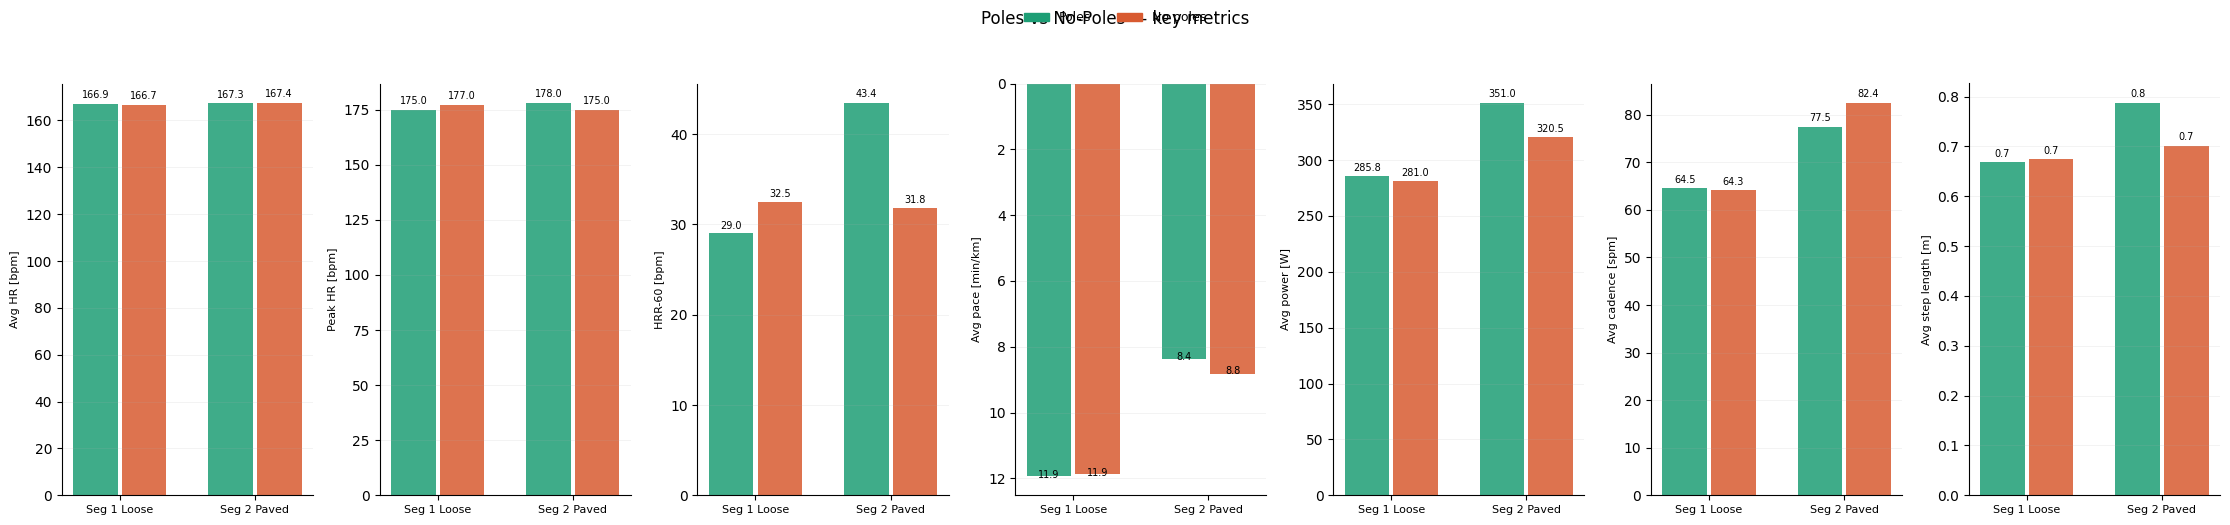

In [16]:
BAR_METRICS = [
    ('hr_mean',        'Avg HR [bpm]'),
    ('hr_max',         'Peak HR [bpm]'),
    ('hrr60_bpm',      'HRR-60 [bpm]'),
    ('pace_mpkm_mean', 'Avg pace [min/km]'),
    ('power_mean',     'Avg power [W]'),
    ('cadence_mean',   'Avg cadence [spm]'),
    ('step_len_m_mean','Avg step length [m]'),
]
BAR_METRICS = [(col, lbl) for col, lbl in BAR_METRICS if col in summary.columns]
n = len(BAR_METRICS)
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 5))
if n == 1: axes = [axes]

for ax, (col, ylabel) in zip(axes, BAR_METRICS):
    for xi, (terrain, t_label) in enumerate([('loose','Seg 1 Loose'),('paved','Seg 2 Paved')]):
        sub = summary[summary['terrain'] == terrain]
        for cond in ['poles','no_poles']:
            row = sub[sub['condition'] == cond]
            if row.empty or col not in row.columns: continue
            val    = row[col].values[0]
            offset = -0.18 if cond == 'poles' else 0.18
            ax.bar(xi + offset, val, width=0.33, color=COLOR[cond], alpha=0.85,
                   label=cond.replace('_',' ') if xi == 0 else None)
            ax.text(xi + offset, val * 1.01, f'{val:.1f}',
                    ha='center', va='bottom', fontsize=7)
    ax.set_xticks([0,1]); ax.set_xticklabels(['Seg 1 Loose','Seg 2 Paved'], fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='y', alpha=0.2, lw=0.5)
    if col == 'pace_mpkm_mean': ax.invert_yaxis()

handles = [Patch(color=COLOR['poles'],    label='Poles'),
           Patch(color=COLOR['no_poles'], label='No poles')]
fig.legend(handles=handles, loc='upper center', ncol=2, fontsize=9, frameon=False)
fig.suptitle('Poles vs No-Poles — key metrics', y=1.04, fontsize=12)
plt.tight_layout()
plt.savefig('summary_bars.png', dpi=200, bbox_inches='tight')
plt.show()

## 9 · Biomechanical scatter — stride efficiency

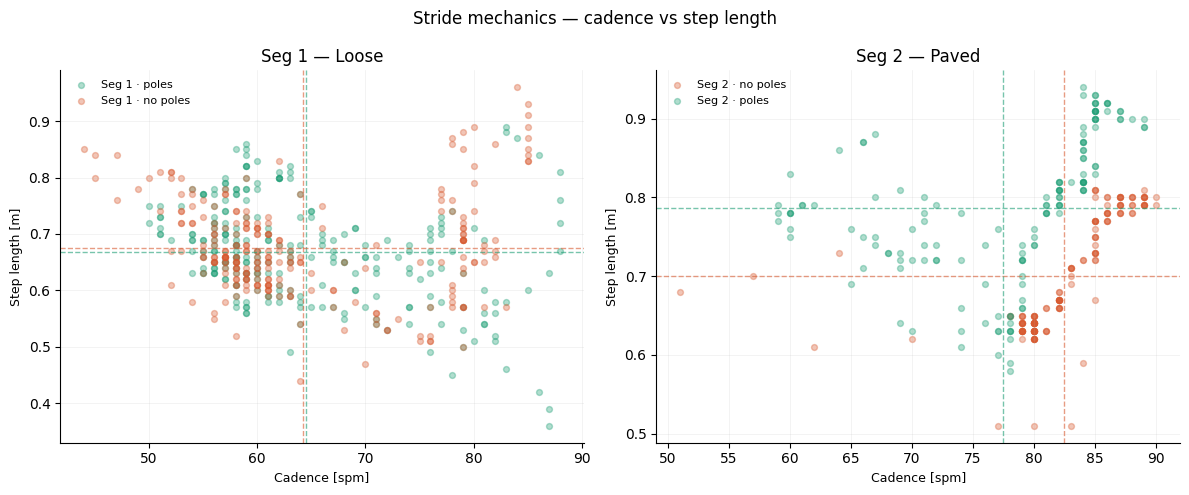

In [17]:
if 'cadence' in df.columns and 'step_len_m' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, terrain_key, t_label in zip(axes,['loose','paved'],['Seg 1 — Loose','Seg 2 — Paved']):
        for key in SEG:
            if SEGMENTS[key]['terrain'] != terrain_key: continue
            seg_df = segments_df[key]
            valid  = seg_df.dropna(subset=['cadence','step_len_m'])
            if valid.empty: continue
            color  = COLOR[SEGMENTS[key]['condition']]
            ax.scatter(valid['cadence'], valid['step_len_m'],
                       c=color, alpha=0.35, s=18, label=SEGMENTS[key]['label'])
            ax.axvline(valid['cadence'].mean(),    color=color, lw=1, ls='--', alpha=0.6)
            ax.axhline(valid['step_len_m'].mean(), color=color, lw=1, ls='--', alpha=0.6)
        ax.set_xlabel('Cadence [spm]', fontsize=9); ax.set_ylabel('Step length [m]', fontsize=9)
        ax.set_title(t_label); ax.legend(fontsize=8, frameon=False)
        ax.grid(True, alpha=0.2, lw=0.5); ax.spines[['top','right']].set_visible(False)
    fig.suptitle('Stride mechanics — cadence vs step length', fontsize=12)
    plt.tight_layout(); plt.savefig('stride_scatter.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print("cadence or step_len_m not available.")

## 10 · Power vs grade

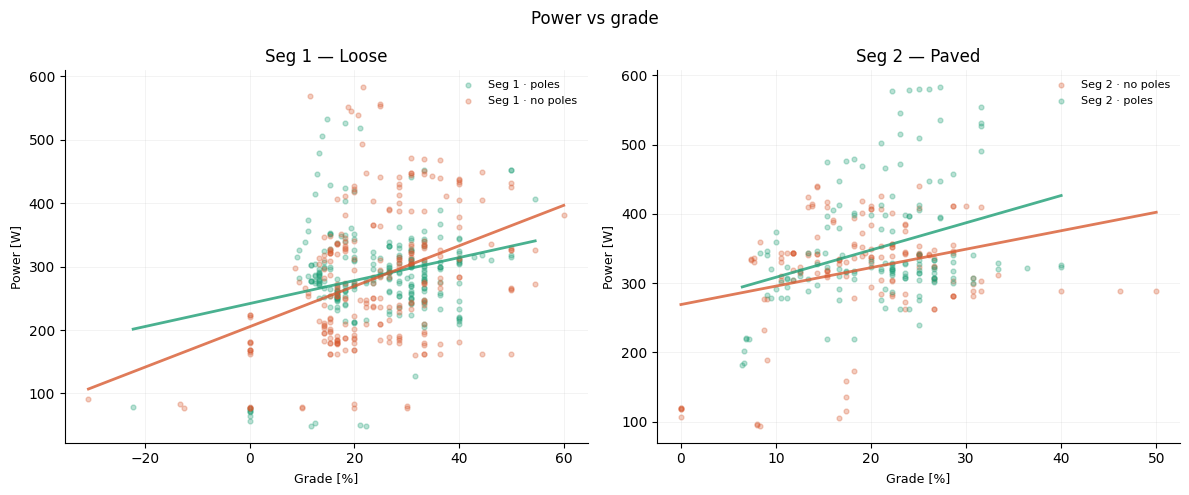

In [18]:
if 'power' in df.columns and 'grade_pct' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, terrain_key, t_label in zip(axes,['loose','paved'],['Seg 1 — Loose','Seg 2 — Paved']):
        for key in SEG:
            if SEGMENTS[key]['terrain'] != terrain_key: continue
            seg_df = segments_df[key]
            valid  = seg_df.dropna(subset=['power','grade_pct'])
            if valid.empty: continue
            color  = COLOR[SEGMENTS[key]['condition']]
            ax.scatter(valid['grade_pct'], valid['power'],
                       c=color, alpha=0.3, s=12, label=SEGMENTS[key]['label'])
            if len(valid) > 5:
                z    = np.polyfit(valid['grade_pct'], valid['power'], 1)
                xfit = np.linspace(valid['grade_pct'].min(), valid['grade_pct'].max(), 100)
                ax.plot(xfit, np.polyval(z, xfit), color=color, lw=2, alpha=0.8)
        ax.set_xlabel('Grade [%]', fontsize=9); ax.set_ylabel('Power [W]', fontsize=9)
        ax.set_title(t_label); ax.legend(fontsize=8, frameon=False)
        ax.grid(True, alpha=0.2, lw=0.5); ax.spines[['top','right']].set_visible(False)
    fig.suptitle('Power vs grade', fontsize=12)
    plt.tight_layout(); plt.savefig('power_grade.png', dpi=200, bbox_inches='tight'); plt.show()
else:
    print("power or grade_pct not available.")

## 11 · Interpretation helper

In [19]:
def interpret(summary):
    lines = []
    for terrain, t_label in [('loose','Loose terrain (Seg 1)'),('paved','Paved (Seg 2)')]:
        sub = summary[summary['terrain'] == terrain]
        if sub.empty: continue
        p   = sub[sub['condition'] == 'poles']
        np_ = sub[sub['condition'] == 'no_poles']
        if p.empty or np_.empty: continue
        lines.append(f"\n{'─'*52}\n {t_label}\n{'─'*52}")
        for col, lbl, note in [
            ('hr_mean',        'Avg HR',        'harder if higher'),
            ('hrr60_bpm',      'HRR-60',        'better recovery if higher'),
            ('pace_mpkm_mean', 'Avg pace',      'faster if lower'),
            ('power_mean',     'Avg power',     'harder if higher'),
            ('cadence_mean',   'Cadence',       ''),
            ('step_len_m_mean','Step length',   ''),
        ]:
            if col not in p.columns: continue
            pv, npv = p[col].values[0], np_[col].values[0]
            delta   = pv - npv
            lines.append(f"  {lbl:<18}: poles={pv:.2f}  no-poles={npv:.2f}  "
                         f"Δ={'+' if delta>=0 else ''}{delta:.2f}  ({note})")
    print('\n'.join(lines))

interpret(summary)


────────────────────────────────────────────────────
 Loose terrain (Seg 1)
────────────────────────────────────────────────────
  Avg HR            : poles=166.87  no-poles=166.70  Δ=+0.17  (harder if higher)
  HRR-60            : poles=29.00  no-poles=32.50  Δ=-3.50  (better recovery if higher)
  Avg pace          : poles=11.92  no-poles=11.88  Δ=+0.04  (faster if lower)
  Avg power         : poles=285.78  no-poles=281.02  Δ=+4.76  (harder if higher)
  Cadence           : poles=64.54  no-poles=64.25  Δ=+0.29  ()
  Step length       : poles=0.67  no-poles=0.67  Δ=-0.01  ()

────────────────────────────────────────────────────
 Paved (Seg 2)
────────────────────────────────────────────────────
  Avg HR            : poles=167.26  no-poles=167.40  Δ=-0.14  (harder if higher)
  HRR-60            : poles=43.44  no-poles=31.80  Δ=+11.64  (better recovery if higher)
  Avg pace          : poles=8.37  no-poles=8.81  Δ=-0.45  (faster if lower)
  Avg power         : poles=350.97  no-poles=320.5

---
## Notes

- **Lap indices**: set `EFFORT_LAP_INDICES` in cell 1. Print all laps with the inspect cell (cell 5) to find the right 0-based positions.
- **Timer-stop trimming**: `extract_segment` detects gaps > `TIMER_STOP_GAP_SEC` (default 5 s) and cuts the segment there, removing any trailing idle time included in the lap boundary.
- **HRR computation**: `compute_hrr` looks for records in the window `[t_end + 55 s, t_end + 65 s]` in absolute wall-clock time — so it finds the first records of the *next* lap that happen to fall in that window. Adjust `HRR_TARGET_SEC` and `HRR_TOLERANCE` in cell 1 if you get NaNs (e.g. if your next lap starts later than 65 s after the stop).
- **Order effect**: Seg 1 ran A→B, Seg 2 ran B→A. The second effort in each pair accumulates fatigue; keep this in mind when comparing HR.